In [11]:
import boto3
import os
s3 = boto3.client(
    's3',
    endpoint_url=os.environ['S3_ENDPOINT_URL'],
    aws_access_key_id=os.environ['AWS_ACCESS_KEY_ID'],
    aws_secret_access_key=os.environ['AWS_SECRET_ACCESS_KEY']
)

In [2]:
!pip install rasterio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 55.7 MB/s eta 0:00:0000:0100:01


In [36]:
import os
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg

In [32]:
# Base directory where the images are stored
base_path = 'Satellite_Data' #data path

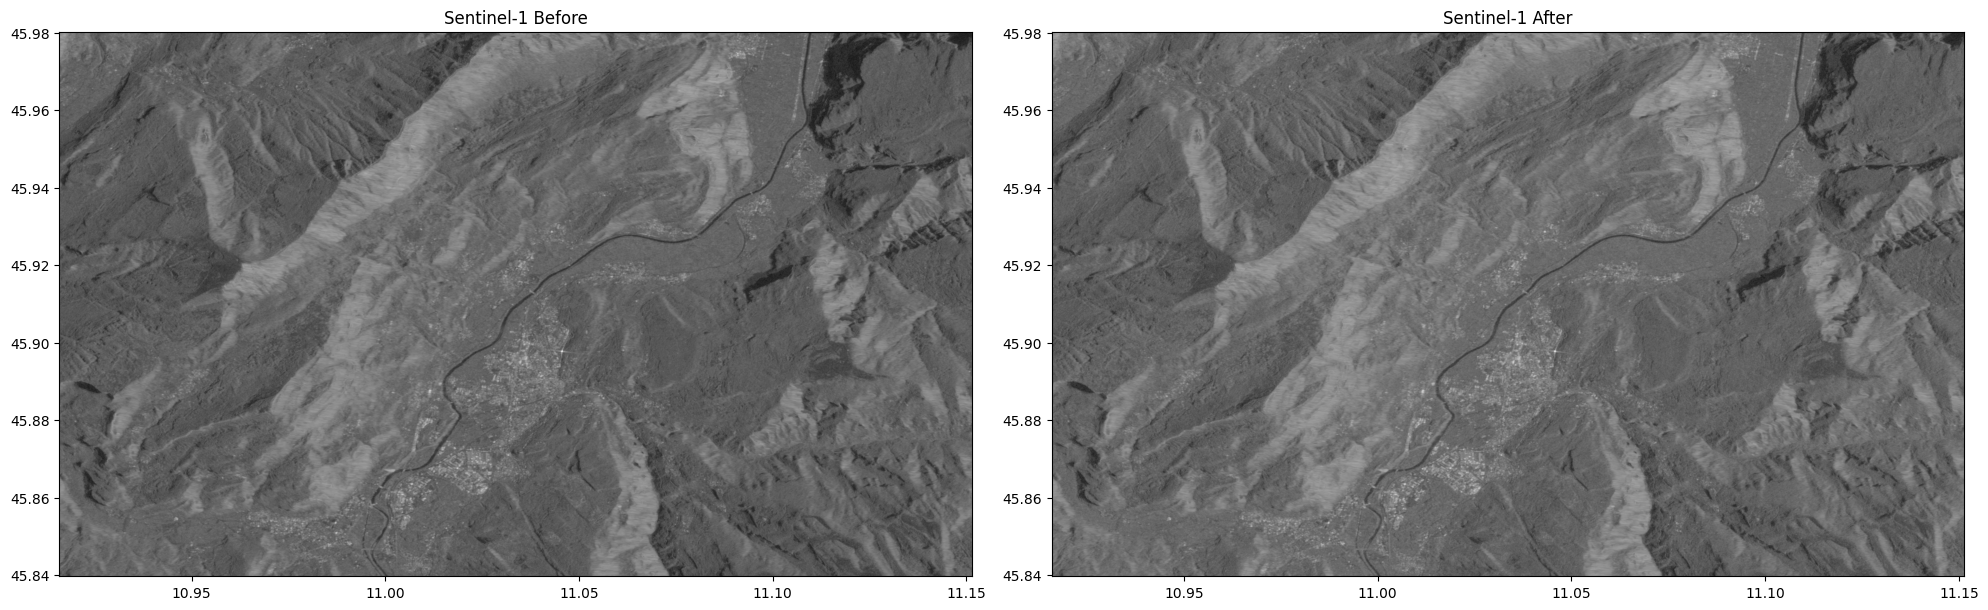

In [33]:
# File names that you want to load
file_names = ['PreFlood_Sentinel1.tif', 'PostFlood_Sentinel1.tif']

# Build full paths by combining the base path with the file names
paths = [os.path.join(base_path, filename) for filename in file_names]

# Titles and colormap configurations for each subplot
configurations = [
    {'title': 'Sentinel-1 Before', 'cmap': 'gray'},
    {'title': 'Sentinel-1 After', 'cmap': 'gray'}
]

# Create a 1x2 grid of images
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Loop through each configuration and image path
for ax, path, conf in zip(axs, paths, configurations):
    with rasterio.open(path) as src:
        # Use the defined colormap and normalization
        show(src, ax=ax, cmap=conf['cmap'])
        ax.set_title(conf['title'])

# Adjust layout for a tight fit
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0765..5.002166666666667].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08333333333333333..2.876333333333333].


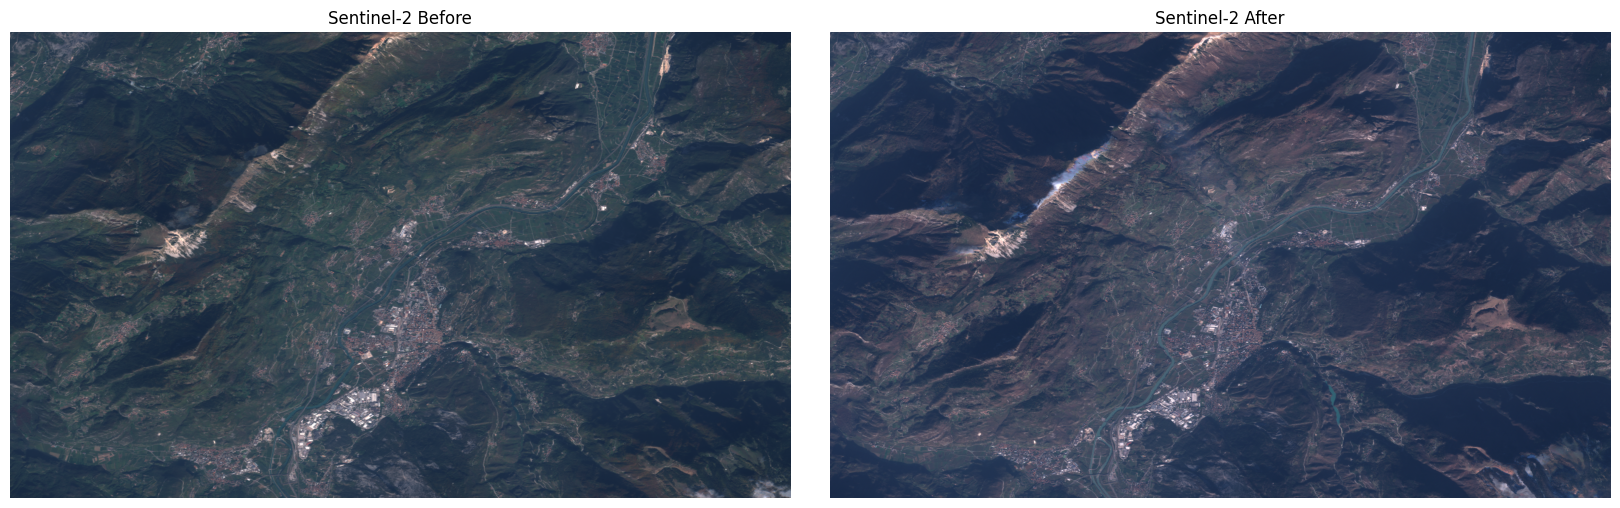

In [25]:
# File names that you want to load
file_names = ['PreFlood_Sentinel2_RGB.tif', 'PostFlood_Sentinel2-p2_RGB.tif']

# Build full paths by combining the base path with the file names
paths = [os.path.join(base_path, filename) for filename in file_names]

# Titles for each image
titles = ['Sentinel-2 Before', 'Sentinel-2 After']

# Create a 1x2 grid of images to show them side by side
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Loop through each file and subplot
for ax, path, title in zip(axs, paths, titles):
    with rasterio.open(path) as src:
        # Read the specific bands for RGB (Bands 4, 3, and 2)
        rgb = src.read([4, 3, 2])  # Ensure these band indices align with your data structure
        # Normalize and display the image
        show(rgb / 3000, ax=ax, transform=src.transform)  # Scale factor for reflectance visualization
        ax.set_title(title)  # Set the title for each subplot
        ax.axis('off')  # Hide axis labels and ticks

# Adjust layout to eliminate space between images
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)
plt.show()


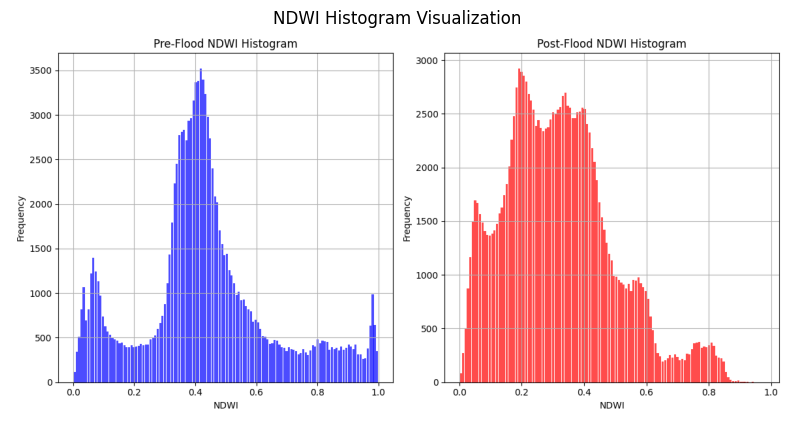

In [37]:
# Assuming the path to your mounted Google Drive and the specific file
file_path = 'Satellite_Data/Histogram_NDWI.png'

# Load and display the image using matplotlib
img = mpimg.imread(file_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # Hide the axes
plt.title('NDWI Histogram Visualization')
plt.show()

/opt/conda/lib/python3.9/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


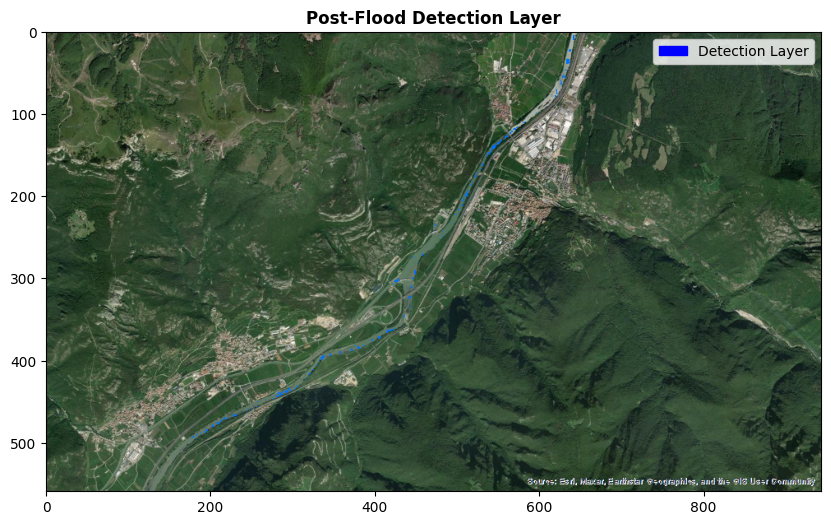

In [38]:
# Assuming the path to your mounted Google Drive and the specific file
file_path = 'Satellite_Data/Change_Map-01.png'

# Open the TIFF file using Rasterio
with rasterio.open(file_path) as src:
    # Display the image
    fig, ax = plt.subplots(figsize=(10, 10))
    show(src, ax=ax, title='Post-Flood Detection Layer')

    # Create a legend for the blue line
    blue_line = mpatches.Patch(color='blue', label='Detection Layer')
    legend = ax.legend(handles=[blue_line], loc='upper right')  # You can adjust the location as needed

    plt.show()

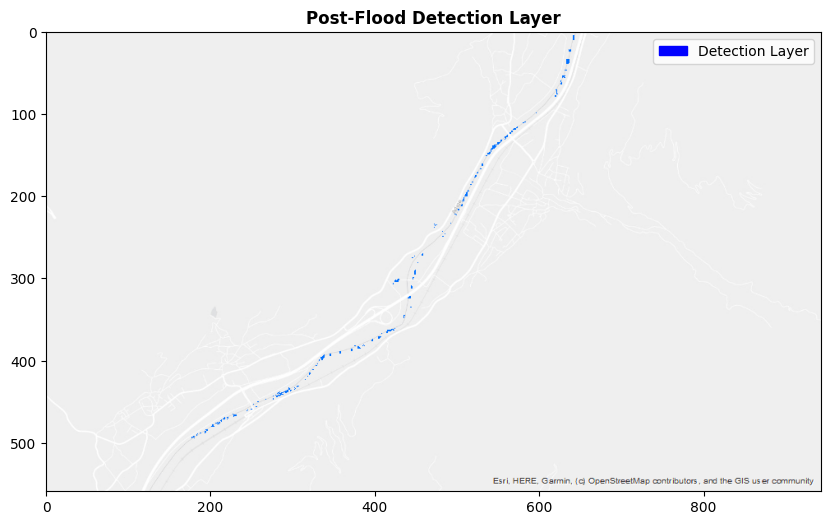

In [39]:
# Assuming the path to your mounted Google Drive and the specific file
file_path = 'Satellite_Data/Change_Map-02.png'

# Open the TIFF file using Rasterio
with rasterio.open(file_path) as src:
    # Display the image
    fig, ax = plt.subplots(figsize=(10, 10))
    show(src, ax=ax, title='Post-Flood Detection Layer')

    # Create a legend for the blue line
    blue_line = mpatches.Patch(color='blue', label='Detection Layer')
    legend = ax.legend(handles=[blue_line], loc='upper right')  # You can adjust the location as needed

    plt.show()